# Feature Extraction

- Feature extraction describes the transformations from **data** to **vectors**

   
- Extracting good features is **more important** than choosing a ML model


- We will cover some standard feature extractors, but there are many more


- Often the best feature extractors include domain knowledge by human experts


- Feature extractors have to be optimized along with all other model parameters
 

## Data Modalities
   
- Continuous Features
- Categorical Features
- Text
- Images
- Not covered here (among many others):
  - Graph data
  - Bioinformatics
  - Time Series
  

## Tabular Features

### Continuous Features

- Continuous features: $x \in R^{d}$


- For many models continuous features don't need to be transformed


- For some models it is necessary or beneficial to **normalize** continuous features

    - When optimizing with stochastic gradient descent
    - When regularizing models: to control regularization

### Normalization: z-scoring

Given a feature $x\in R^1$ (and for multivariate $x$ analogously) there are several standard normalization options:

**Standard scaling / z-scoring**: compute mean $\mu_x$ and standard deviation $\sigma_x$ of $x$ and compute

$$ x \leftarrow \frac{(x - \mu_x) } {\sigma_x} $$

- Resulting variable has zero mean and unit variance
- See [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
     


In [1]:
from sklearn.preprocessing import StandardScaler
data = [[0, 0], [0, 0], [1, 1], [1, 1]]
scaler = StandardScaler()
scaler.fit(data)
print("Estimated Mean: {}".format(scaler.mean_))
scaler.transform([[.5, .5], [2,2]])

Estimated Mean: [0.5 0.5]


array([[0., 0.],
       [3., 3.]])

### Normalization: Min-Max Scaling   

**Min-max scaling**: compute min $\text{min}_x$ and max $\text{max}_x$ of $x$

$$ x \leftarrow \frac{(x - \text{min}_x) } {\text{max}_x - \text{min}_x} $$

- Resulting variable is in range [0,1] (or any other range)
- See [sklearn.preprocessing.MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)



### Categorical Features

Categorical features are variables $x \in \{ 0,1,2,\dots, N\}$ taking one value of a set of cardinality $N$ without an implicit ordering e.g.:
- colors (red, green, blue)
- user ids
- Movie ids

Often used feature transformations are 

- One-hot encoding

- More recently for neural networks: low dimensional embeddings


### One-hot encoding

Given a set of values [red, green, blue], we transform the data into 

- red $\leftarrow$ [1,0,0]
- green $\leftarrow$ [0,1,0]
- blue $\leftarrow$ [0,0,1]

Sets of categorical variables can be represented as sum over single value vectors.

Examples: bag-of-words vectors


In [2]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
X = [['red'], ['green'], ['blue'], ['red']]
enc.fit(X)
enc.transform([['red'], ['green'], ['blue']]).toarray()

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])

### One-hot encoding: Problems

- Cardinality needs to be estimated upfront
- New items / categories cannot be represented
- Similarity information is lost (light-blue and blue as different as black and white)

## Feature Extraction for Text

- Bag-of-Words
- Hashed Bag-of-Words
- (Continuous Bag-of-words)


### Bag-of-Words Features

Count word (=token) occurrences

> "Good artists copy. Great artists steal."


|good|artists |copy | great | steal|
|---|---|--------|-----|--------|
|1  |2  | 1      |1    |   1    |
 

- Only accounts for word histogram
- Most of language structure lost
- Very efficient 

### Bag-of-Words Model with N-Grams

Count n-gram occurrences can account for some language structure

> "Good artists copy. Great artists steal."


|good|artists |copy | great | steal| good artists|great artists|...|
|---|---|--------|-----|--------|----|-----|---|
|1  |2  | 1      |1    |   1    | 1 |1|...|

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
corpus = [
     'This is the first document.',
     'This document is the second document.',
     'And this is the third one.',
     'Is this the first document?']
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print("Vocabulary: {}".format(vectorizer.get_feature_names_out()))
X.toarray()

Vocabulary: ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']


array([[0, 1, 1, 1, 0, 0, 1, 0, 1],
       [0, 2, 0, 1, 0, 1, 1, 0, 1],
       [1, 0, 0, 1, 1, 0, 1, 1, 1],
       [0, 1, 1, 1, 0, 0, 1, 0, 1]])

### Character N-Grams

Instead of words as tokens you can take characters as tokens


> "Good artists copy. Great artists steal."


|g  | go | oo | od | ar|...|
|---|---|---|----|---|---|
|2  |1  | 1 |1   | 1 |...|

Very powerful for language-independent models!

### Term Frequency / Inverse Document Frequency


Frequently occurring words (like ``the``) are often not very meaningful and are often weighted down by the **inverse document frequency**:


- Term frequency:

    $ \text{tf}(t,d) $: Frequency of a term $t$ in document $d$
    

- Inverse document frequency:

    $\text{idf} (t,d)=\log {\frac {|\text{Number of documents}|}{|\text{Number of Documents containing }t|}}$
    

### Alternatively: Stopwords

Just exclude some frequent meaningless words from the text. 

### N-Grams are expensive

$V=$ number of tokens in your vocabulary (usually 1e4 to 1e6 for good models)
- unigrams: all tokens

    Memory requirement for n-gram counts: $V$


- bigrams: all ordered pairs of **two** tokens

    Memory requirement for n-gram counts: $V^2$


- trigrams: all ordered pairs of **three** tokens

    Memory requirement for n-gram counts: $V^3$


- ...


See [Google's n-gram corpus](http://storage.googleapis.com/books/ngrams/books/datasetsv2.html) (up to 5-grams for many languages).

### Hashed N-Grams

- Instead of counting all n-grams: Use a HashMap

- Each token gets hashed, count of hash-bucket incremented

- Advantages:
    - Full control over memory footprint (often small HashMaps work surprisingly well)
    - No need to compute a dictionary
    
    
- Disadvantages:
    - Hash collisions: multiple n-gram map to the same bucket
    - No Tf-Idf weighting: 



See [Scikit-Learn's HashingVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.HashingVectorizer.html)

## Feature Extraction for Images

- Classical features (e.g. HOG)

- CNN features
  

### Classical Computer Vision Feature Extractors

Histograms of Oriented Edges (HOG) descriptors capture shape very well. 

HOG features, just like most other oldschool vision feature descriptors, perform poorly compared to neural networks

Still, they could be helpful if shape on standardized images is the only relevant feature
  

In [13]:
from skimage.feature import hog
from skimage import data, exposure, io

image = io.imread("figures/turing.png")

fd, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16),
    cells_per_block=(1, 1), visualize=True, channel_axis=-1)

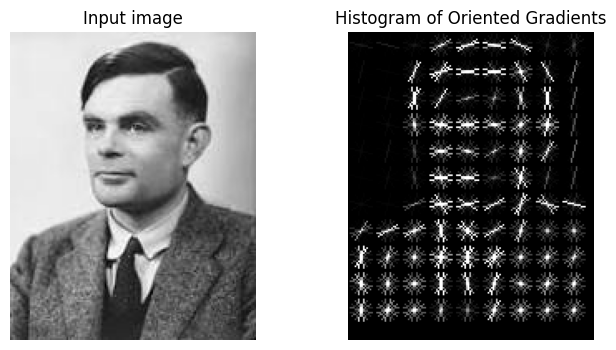

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

### Convolutional Neural Networks

State of the art in computer vision are convolutional neural networks

We don't have time in this lecture to go into detail (see e.g. Kristian Hildebrand's lecture)

And most people don't have the compute to train those models from scratch

But pretrained models are good feature extractors - which doesn't require training

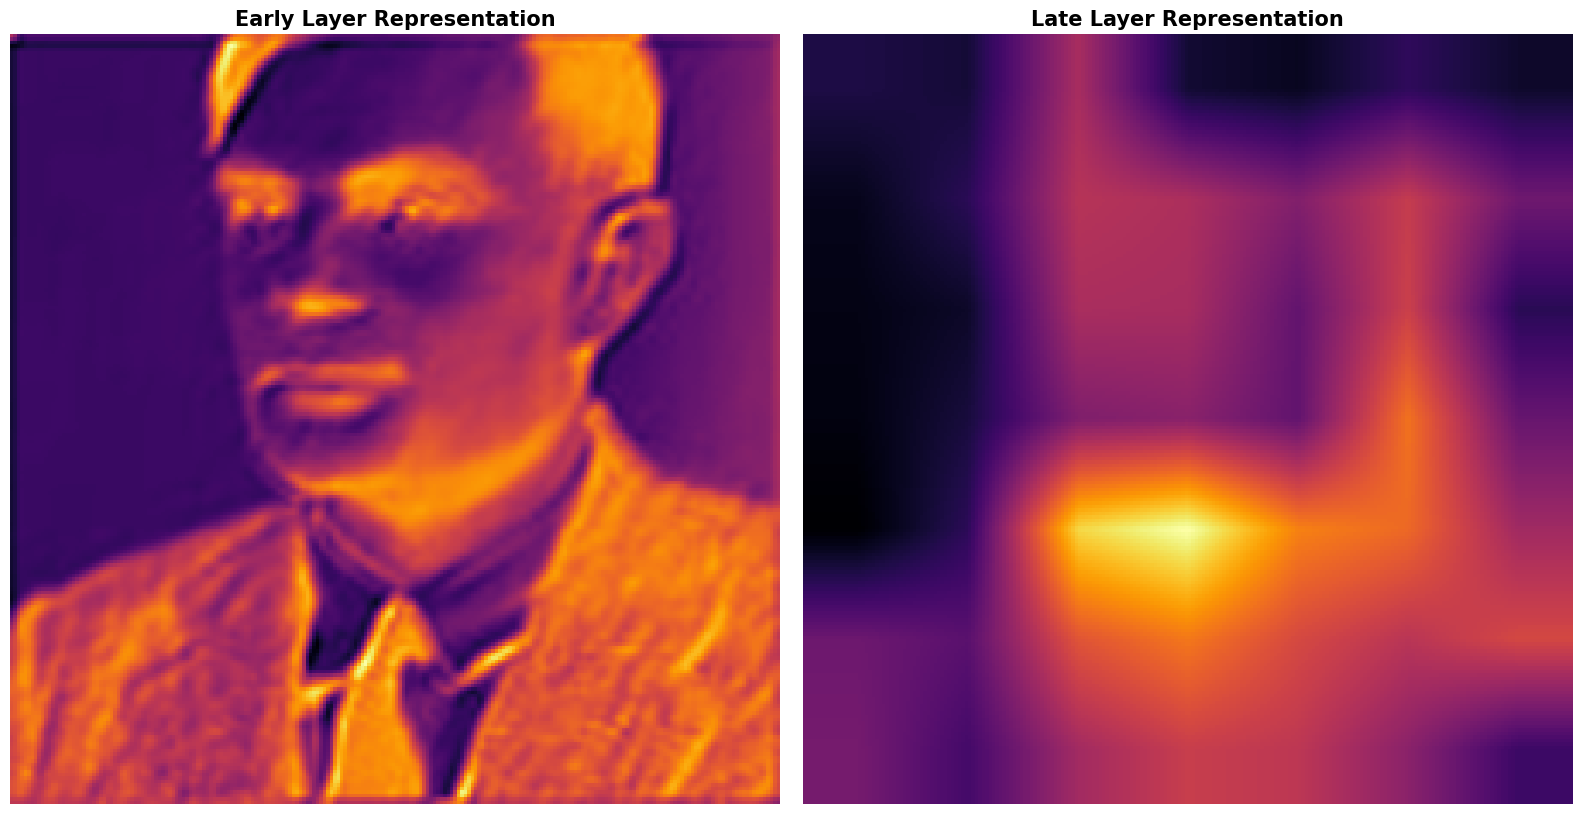

In [10]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch.nn.functional as F

# 1. Setup Model and Hooks
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).eval()
activations = {}

def hook_fn(name):
    def hook(m, i, o): activations[name] = o.detach()
    return hook

# Register hooks: Early (conv1) and Late (layer4)
model.conv1.register_forward_hook(hook_fn("Early"))
model.layer4[-1].register_forward_hook(hook_fn("Late"))

# 2. Forward Pass
img_path = 'figures/turing.png' # Replace with your image
img = Image.open(img_path).convert("RGB")
preprocess = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(), 
                        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
x = preprocess(img).unsqueeze(0)
_ = model(x)

# 3. Horizontal Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, name in zip(axes, ["Early", "Late"]):
    # Average across channels and upsample
    feat = activations[name].mean(dim=1).squeeze().numpy()
    feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8) # Normalize
    
    # Upsample to image size for visualization
    feat_img = F.interpolate(torch.tensor(feat).view(1, 1, *feat.shape), 
                             size=(224, 224), mode='bilinear').squeeze().numpy()
    
    ax.imshow(feat_img, cmap='inferno')
    ax.set_title(f"{name} Layer Representation", fontsize=15, fontweight='bold')
    ax.axis('off')
    
plt.savefig('figures/turing-convnet.png')
plt.tight_layout()
plt.show()

### What individual layers capture:
![Turing ConvNet](figures/turing-convnet.png)
* Early Layer (conv1): This layer is essentially a collection of Gabor filters and edge detectors. The resulting activation map highlights high-frequency details, borders, and gradients in the image.
* Late Layer (layer4): By the time information reaches the final residual block, the spatial dimensions have been compressed (e.g., from 224 to 7 pixels). The activations here are spatially coarse but semantically rich; they respond to the presence of specific object parts or abstract concepts, ignoring the fine-grained edge details captured early on.

# Summary

- Machine Learning models consume data as vectors 
- Feature Extraction Methods discussed here:
     - Continuous Features
     - Categorical Features
     - Text
     - Images
  